Nitrogen
77.3


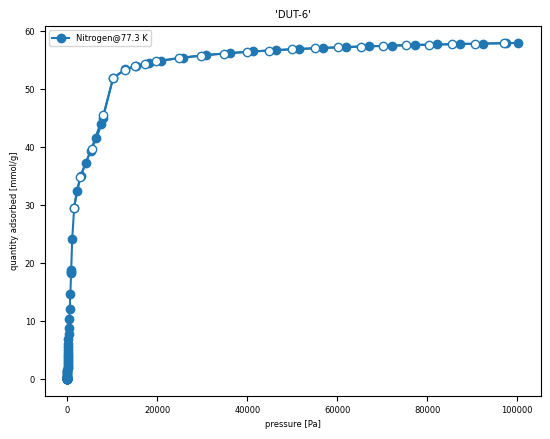

In [4]:
import numpy as np
from gemmi import cif
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 6})

aif = cif.read_file("isotherm.aif")
block = aif.sole_block()

ads_press = np.array(block.find_loop('_adsorp_pressure'), dtype=float)
ads_amount = np.array(block.find_loop('_adsorp_amount'), dtype=float)
des_press = np.array(block.find_loop('_desorp_pressure'), dtype=float)
des_amount = np.array(block.find_loop('_desorp_amount'), dtype=float)

material_id = block.find_pair('_adsnt_material_id')[-1]
adsorptive = block.find_pair('_exptl_adsorptive')[-1]
temperature = block.find_pair('_exptl_temperature')[-1]
print(adsorptive)
print(temperature)
plt.plot(ads_press, ads_amount, 'o-', color="C0", label=f"{adsorptive}@{temperature} K")
plt.plot(des_press, des_amount, 'o-', color="C0", markerfacecolor="white")
plt.legend()
plt.ylabel(f"quantity adsorbed [{block.find_pair('_units_loading')[-1]}]")
plt.xlabel(f"pressure [{block.find_pair('_units_pressure')[-1]}]")
plt.title(material_id)
plt.show()